# One-sparse Dictionary-based Low-Rank Approximations

:::{admonition} Reference
:class: tip

ref
:::


```{note}
Out of simplicity, we present only the matrix case, but both one-sparse dictionary-based matrix and tensor low-rank decompositions are studied in our work {cite}`cohenDictionarybasedTensorCanonical2018`. In particular we show that one-sparse DLRA is a well-posed approximate tensor decomposition problem contrary to approximate CPD. Also note that this work has been studied against global optimization solutions in 2023 {cite}`dacheExactHeuristicMethods2023`.
```

We are interested in solving the following matrix factorization problem:

$$ \min_{B\in\Omega_B, \mathcal{K}\in [1,d]^{r}} \| Y - D[:,\mathcal{K}]B^T \|_F^2 $$ 
where $\Omega_B$ is typically $\mathbb{R}^{n\times r}$ or $\mathbb{R}^{n\times r}_+$ with $r\leq m,n$.

This problem, coined one-sparse DLRA, consists in finding the columns of the dictionary $D$ indexed in the set $\mathcal{K}$ such that the data matrix $Y$ is well approximated by a low-rank model $D[:,\mathcal{K}]B^T$. One can also rewrite one-sparse DLRA using a selection binary matrix $S$ which columns have a single nonzero element at each $\mathcal{K}[q]$ for $q\in[1,r]$, this yields $D[:,\mathcal{K}]B^T=DSB^T$.

The code snippet below shows how to generate such a data matrix $Y$ without noise. We use an hyperspectral image available in `tensorly.dataset`, and assume that a few pixels are pure. This means that the spectra source matrix $A$ is contained in the data iteself, in other words $A=D[:,\mathcal{K}]$ but $\mathcal{K}$ is unknown.


Showing the hyperspectral image at band indexed by 70
Red crosses signal the position of the hand-picked pure pixels


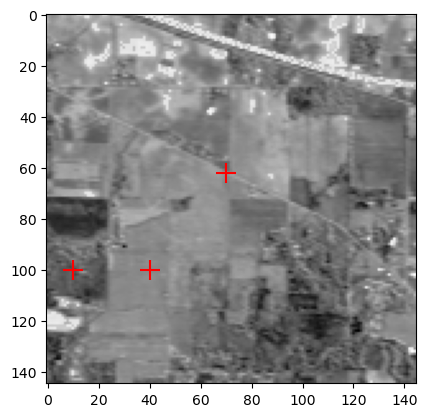

Showing 3 pixels (spectra) indexed by [9060, 14540, 14510]


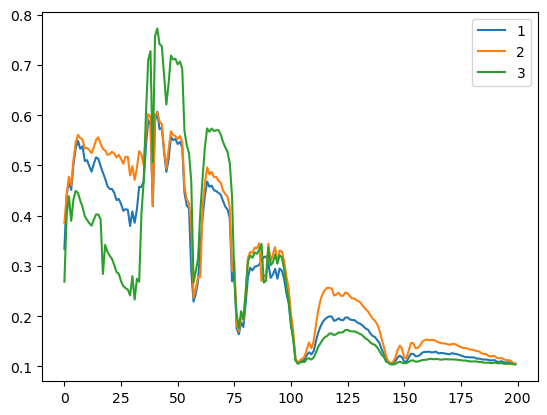

In [ ]:
import numpy as np
import tensorly as tl
from tensorly.datasets import data_imports 
import matplotlib.pyplot as plt
from tensorly_hdr.image_utils import convert_to_pixel, convert_to_index

# Import an hyperspectral image
image_bunch = data_imports.load_indian_pines()
image_t = image_bunch.tensor # x by y by wavelength
image_t = image_t/tl.max(image_t) # maximum value set to 1

# Vectorize the tensor into a m\times n matrix (wavelength \times pixels, y vary first)
image = tl.unfold(image_t, 2)

# Simulation parameters
# For illustration purpuses we can pick a few spectra and build a synthetic data matrix accordingly.
band = 70
rank = 3
# hand-picked road, field and forest
Kx = [70,40,10]
Ky = [62,100,100]
K = convert_to_index(Kx, Ky, image_t.shape[1])

# Show the hyperspectral image at a given band
plt.figure()
print("Showing the hyperspectral image at band indexed by", band)
print("Red crosses signal the position of the hand-picked pure pixels")
plt.imshow(image_t[:,:,band], cmap="Greys")
# Also showing the pixels we hand-pick as pure
plt.scatter(Kx, Ky, s=200, c='red', marker='+')
plt.show()
# Show spectra from selected pixels
plt.figure()
print(f"Showing {rank} pixels (spectra) indexed by {K}")
plt.plot(image[:, K])
plt.legend(["1","2","3"])
plt.show()

In [98]:
from tensorly_hdr.image_utils import sparsify
Bt = np.random.rand(rank, image.shape[1]) # elementwise nonnegative
# We sparsify B so that not all pixels use all three spectra, this is optional
Bt = sparsify(Bt, s=0.5)
Y = image[:,K]@Bt

The columns of matrix $Y$ are now indeed linear combinations of only three columns in the dictionary $D$ (which is the original hyperspectral image itself in this particular case). The DLRA problem consists in finding the indices $\mathcal{K}$, the pure pixels indices, and the abundances $Bt$.

```{note}

The one-sparse DLRA model under scrutiny in this section has strong connections with many other matrix and tensor factorization models, most prominently the Multiple Measurements Vector (MMV) also called collaborative sparse coding. This connection is explored in {cite}`cohenDictionarybasedTensorCanonical2018`. In a nutshell, MMV does not assume that the data is low-rank. On the other hand, MMV transforms the bi-variate problem into a single convex problem over the $SB^T$ matrix, which can be solved optimally but typically involves many more variables and requires guarantees for the correctness of the convex relaxation. Interested readers can refer to this publication for more details.

```

## Identifiability of one-sparse DLRA

Formally, there are a number of interesting question to be answer upon inspecting one-sparse DLRA:
- In general low-rank approximations are not interpretable because of the rotation ambiguity. For the one-sparse DLRA model, does the sparsity constraint leads to identifiability?
- May an algorithm be designed that finds optimal solutions in reasonable time?

We first answer positively to the identifiability question under mild conditions on the dictionary.

```{prf:theorem}
:label: onesparse_identif

Let $Y$ be a real $m\times n$ matrix of rank $r$, and let $D$ be a real $m\times d$ matrix with $\text{spark}(D)>r$ where $\text{spark}(D)$ is the minimum integer $k$ such that at least one subset of $k$ columns of matrix $D$ is rank-defficient. If there exist a full column-rank permutation matrix $S$ (columns are one sparse and entries are binary) and a matrix $B\in\R{n\times r}$ with nonzero columns such that $Y=(DS)B^T$, then $S$ and $A$ are unique up to permutation ambiguity.

See {cite}`cohenDictionarybasedTensorCanonical2018` for the proof.
```

In other words, for a well-built dictionary with incoherent atoms, the dictionary constraint leads to uniqueness of the matrix factorization problem.

## A simple heuristic for one-sparse DLRA

Designing an optimization algorithm with performance guarantees for one-sparse DLRA is not an easy task, in particular since one-sparse DLRA is a generalization of sparse coding (sparse coding is recovered when $n=1$). While we can think of convex relaxations for the sparsity constraints, empirically we found that a heuristic based on alternating least squares works rather well. In what follows we introduce this heuristic, coined Maximum Correlation ALS (MC-ALS), and showcase its performance on spectral unmixing. However, we defer a theoretical analysis of xxx to the next section that deals with the k-sparse DLRA problem [todo] crossref.

```{margin}
The original name of MC-ALS in {cite}`cohenDictionarybasedTensorCanonical2018` was Matching Pursuit ALS, which is somewhat missleading since there is essentially only one iteration of Matching Pursuit involved, and the global algorithm is not greedy.
```

MC-ALS works as follows: we view the submatrix $D[:,\mathcal{K}]$ as a factor matrix $A$, and optimize over $A$ using a least-sqsuares estimate

$$ \hat{A} = \text{argmin}_{A} \| Y - AB^T\|_F^2. $$

If in the application at hand matrix $A$ should be nonnegative (such as spectra in our running hyperspectral image example), we may use a nonnegative least squares solver instead.

Then given an estimation $\hat{A}$, the closest atom in the dictionary $D$ is computed for each column of $A$

$$ \mathcal{K}[i] = \text{argmin}_{j\leq d} |D[:,j]^TA[:,i]|. $$

This formula assumes that the dictionary has l2-norm normalized columns.

```{note}

Using the largest absolute scalar product between the atoms and the estimated factor matrix $\hat{A}$ may lead to selecting the same atom twice, e.g. if two columns of $\hat{A}$ are similar. This problem can be alleviated by rather selecting indices $\mathcal{K}$ as the optimal linear assignement of atoms in the dictionary $D$ to columns of matrix $\hat{A}$:

$$ \mathcal{K} = \text{argmin}_{\mathcal{K}} \text{Tr}(|D[:,\mathcal{K}]^TA|) $$

This problem is solved efficiently using for instance the Hungarian algorithm [todo] ref. In the original work {cite}`cohenDictionarybasedTensorCanonical2018` we did not use a linear assignement problem solver, but it is used here since it avoids singularity of the estimated factor.

```
This yields the following routine to estimate matrix $A$ given an estimation for $B$.

In [99]:
from scipy.optimize import linear_sum_assignment
# scipy is a dependency of tensorly

def MC_ALS_Aestimation(Y, D, B, nonnegative=True):
    # Ensure the dictionary has normalized columns
    if nonnegative:
        Ahat = tl.solvers.hals_nnls(B.T@(Y.T), B.T@B, n_iter_max=20).T
    else:
        Ahat = tl.solve(B.T@B,B.T@(Y.T)).T
    #K = []
    #for i in range(Ahat.shape[1]):
    #    K.append(np.argmax(np.abs(D.T@Ahat[:,i])))
    K, _ = linear_sum_assignment(tl.abs(D.T@Ahat), maximize=True)
    Ahat2 = D[:,K]
    return K, Ahat2, Ahat

D = image/np.linalg.norm(image,axis=0)    
B = Bt.T
print(B.shape, Y.shape)
out = MC_ALS_Aestimation(Y, D, B)
print(out[0])

(21025, 3) (200, 21025)
[ 9060 14510 14540]


In the code snippet above, we are able to recover the indices of the atoms that we hand-picked earlier. However we assumed that matrix $B$ is known, and no noise was added to the system. 



The full algorithm requires the estimation also of matrix $B$. Because we work here with hyperspectral images and both spectra and abundances are nonnegative, we use a nonnegative least squares solver to estimate $B$ rather than ordinary least squares.

In [100]:
def MC_ALS(Y, D, B_0, itermax=100):
    errs = []
    B = np.copy(B_0)
    for it in range(itermax):
        # estimate A
        K, A, _ = MC_ALS_Aestimation(Y, D, B)
        # estimate B
        #B = tl.solve(A.T@A, A.T@Y).T
        B = tl.solvers.hals_nnls(A.T@Y, A.T@A, n_iter_max=20).T
        # compute error
        errs.append(tl.norm(Y - A@B.T)**2/tl.prod(Y.shape))
        # stop if error has not changed at all (algorithm is stuck)
        if it>1 and errs[-2]==errs[-1]:
            print("Final estimated indices", K)
            print("MSE", errs[-1])
            break
    return (None, [A, B]), errs, K

out = MC_ALS(Y, D, np.random.rand(*B.shape))

Final estimated indices [ 4116 14510 14540]
MSE 7.58861024787548e-06


We can compare the indices of the stoms selected by MC_ALS with the (synthetic) ground truth.

In [101]:
print(K, out[2])

[9060, 14540, 14510] [ 4116 14510 14540]


If one runs the experiment several times, one might observe that the ground truth is often only partially recovered despite the absence of noise. Moreover the results are surpisingly consistant between each run. We can place the selected pixels on the hyperspectral image (in green) and plot the corresponding spectra. Notice how the selected pixels sometimes still appear to belong to the same class as the ground truth (road, forest, field).

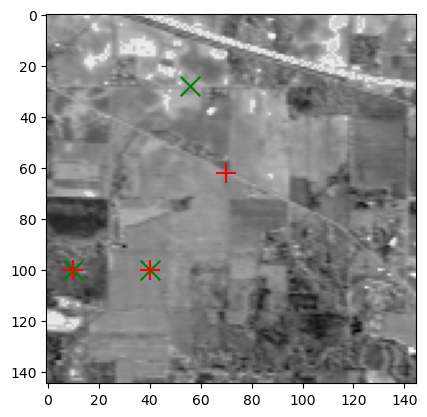

Showing 3 pixels (spectra) indexed by [9060, 14540, 14510]


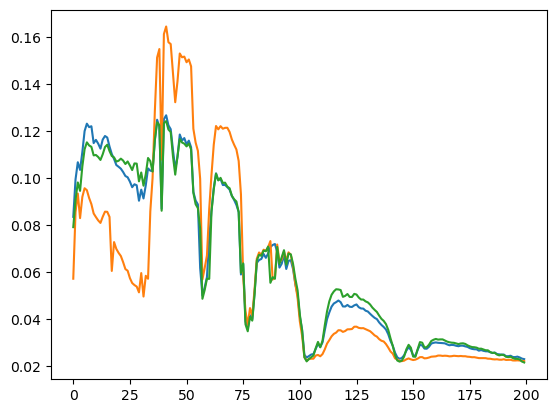

In [102]:
Kxe, Kye = convert_to_pixel(out[2], image_t.shape[1])
plt.figure()
plt.imshow(image_t[:,:,band], cmap="Greys")
# Also showing the pixels we hand-pick as pure
plt.scatter(Kxe, Kye, s=200, c='green', marker='x')
plt.scatter(Kx, Ky, s=200, c='red', marker='+')
plt.show()
# Show spectra from selected pixels
plt.figure()
print(f"Showing {rank} pixels (spectra) indexed by {K}")
plt.plot(out[0][1][0])
plt.show()

A typical issue with MC-ALS is that the algorithm is often stuck after only a few iterations. Indeed during an iteration where $A$ changes slightly but the selected atom are the same as in the previous iteration, at the end of this iteration the estimates $A$ and $B$ are identical to the estimates of the previous iteration. We can tackle this issue by using a more flexible formulation or a convex relaxation, but empirical performances of these variants are similar or worse in our experience. This phenomenon can be observed in the toy experiment above, see below the printed number of iterations before the MC-ALS algorithm got stuck.

In [103]:
print(len(out[1]))

7
